In [40]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
def f(x):
  return 3*x**2 - 4*x + 5

In [42]:
f(3.0)

20.0

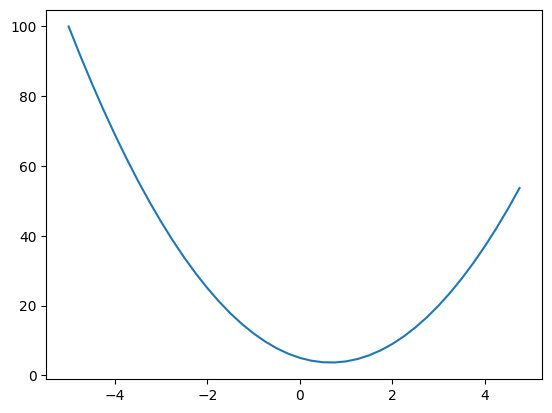

In [43]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [44]:
h = 0.00000000001
x = 2/3
(f(x+h) - f(x))/h

0.0

In [45]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [46]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [147]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    # by initializing to 0 we assume that at beginning, each variable
    # has no effect on the output i.e. we assuming changing this variable
    # does not change the loss function L
    self.grad = 0.0

    # karpathy says it is a tuple in the args and a set here
    # for efficiency reasons
    self._prev = set(_children)
    self._op = _op
    self.label = label

    # function which does the chain rule, stores how we
    # chain the output's grad into the input's grads
    # this is a function that does not do anything
    self._backward = lambda: None

  def __repr__(self):
    # repr is used internally by python to just return this string
    # without this you would get an ugly expression as an output
    # repr gives a way for us to print a nicer looking expression
    return f"Value(data={self.data})"

  def __add__(self, other):
    # when we use the '+' operator, python internally calls a.__add__(b)
    # if other is not an instance of Value we are going to assume it is an integer
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    # we want out._backward to be the function that propagates the gradient
    def _backward():
      # local derivative * derivative of final output of expression wrt out
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    # we dont want to call the function, we just want to store it so no ()
    out._backward = _backward

    return out

  # if you do a + 2, python calls a.__add__(2) which we account for using the
  # isinstance line above but if you do 2 + a, python calls 2.__add__(a) which we
  # do not account for. So, __radd__ acts like a fallback so that if python cannot
  # do 2 + a, it will check if it can do a + 2
  def __radd__(self, other): # other + self
    return self + other

  def  __mul__(self, other):
    # when we use the '*' operator, python internally calls a._mul__(b)
    # if other is not an instance of Value we are going to assume it is an integer
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      # local derivative * derivative of final output of expression wrt out
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    # we dont want to call the function, we just want to store it so no ()
    out._backward = _backward

    return out

  # if you do a * 2, python calls a.__mul__(2) which we account for using the
  # isinstance line above but if you do 2 * a, python calls 2.__mul__(a) which we
  # do not account for. So, __rmul__ acts like a fallback so that if python cannot
  # do 2 * a, it will check if it can do a * 2
  def __rmul__(self, other): # other * self
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += other * (self.data**(other-1)) * out.grad

    out._backward = _backward

    return out

  def __truediv__(self, other): # self / other
    return self * other**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      # local derivative * derivative of final output of expression wrt out
      # d/dx(tanh(x)) = 1 - tanh(x)^2
      self.grad += (1 - t**2) * out.grad

    # we dont want to call the function, we just want to store it so no ()
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      # d/dx(e^x) = e^x
      self.grad += out.data * out.grad

    out._backward = _backward
    return out

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __rsub__(self, other): # other - self
    # we need to preserve order since subtraction is not commutative
    # 2.__sub__(a) falls back to a.__rsub__(2) where 2 is other and a is self
    return other + (-self)

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d*f
L.label = 'L'
L
# (a.__mul__(b)).__add__(c)

Value(data=-8.0)

In [48]:
axp = Value(2.0)
a.exp()

Value(data=7.38905609893065)

In [49]:
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [50]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [51]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [52]:
d._op

'+'

In [53]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name=uid + n._op, label=n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2))+n2._op)

  return dot

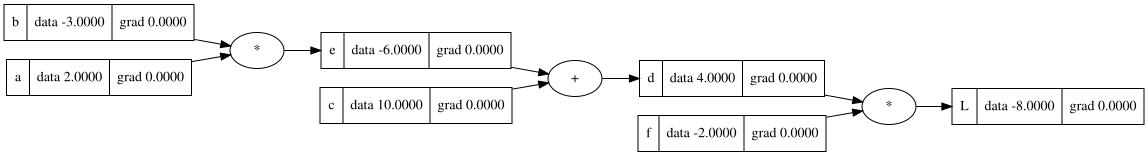

In [54]:
draw_dot(L)

In [55]:
# dL/dL = 1
L.grad = 1.0

In [56]:
# L = d*f

# dL/df = d = 4.0
f.grad = 4.0

# dL/dd = f = -2.0
d.grad = -2.0

In [57]:
# d = e+c
# dd/de = 1
# dd/dc = 1

# dL/dc = dL/dd * dd/dc (chain rule)
c.grad = -2.0 * 1

# dL/de = dL/dd * dd/de (chain rule)
e.grad = -2.0 * 1

# you can look at a '+' node this way: it just routes
# the gradient because the '+' node's local derivatives are
# just 1 and so in the chain rule 1 * dL/dd is just dL/dd! So,
# the derivative just gets routed to c and e in this case.

In [58]:
# e = a*b
# de/da = b = -3.0
# de/db = a = 2.0

# dL/da = dL/de * de/da (chain rule)
a.grad = -2.0 * -3.0

# dL/db = dL/de * de/db (chain rule)
b.grad = -2.0 * 2.0

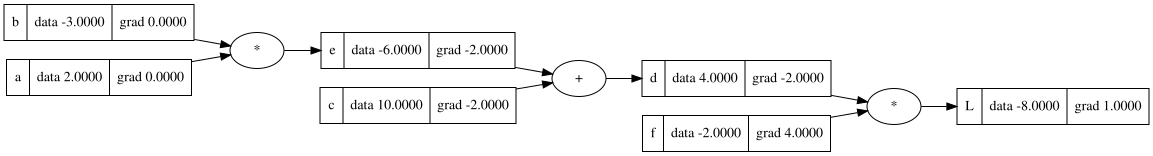

In [59]:
draw_dot(L)

In [60]:
# just nudging all inputs in the direction of the gradient
# we expect a less negative L
# because moving in the direction of the gradient increases the output value

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
d.data += 0.01 * d.grad

e = a*b
d = e + c
L = d*f

print(L.data)

-36.2752


In [61]:
def lol():
  """
  helper function to help analyze the how the gradient changes
  when the value of a variable changes
  """
  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b
  e.label = 'e'
  d = e + c
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f
  L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b
  e.label = 'e'
  d = e + c
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f
  L.label = 'L'
  L2 = L.data

  print((L2-L1)/h)

lol()

-3.9999999999995595


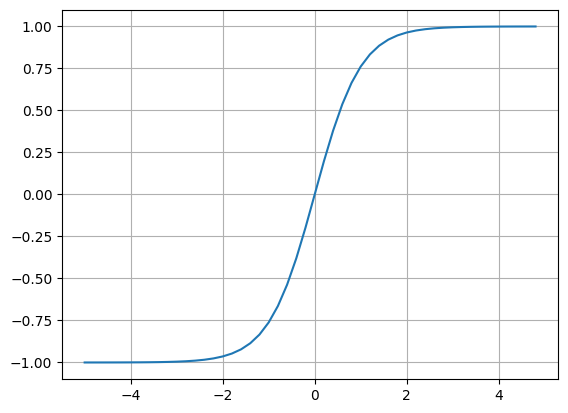

In [62]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [103]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1
x1w1.label = 'x1*w1'
x2w2 = x2*w2
x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

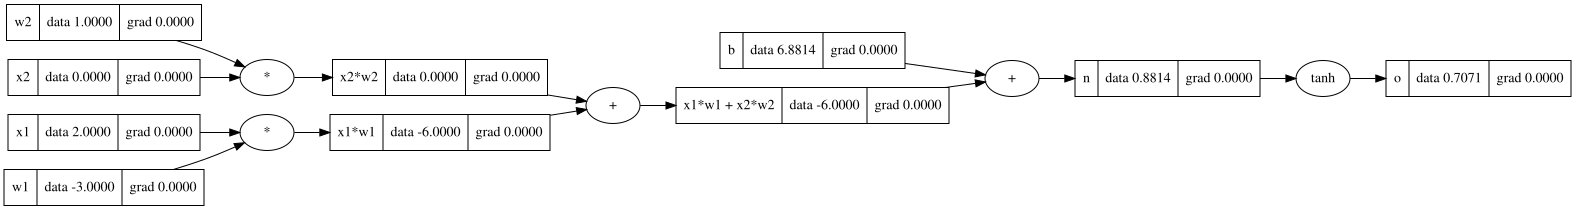

In [64]:
draw_dot(o)

### manual implementation of backprop

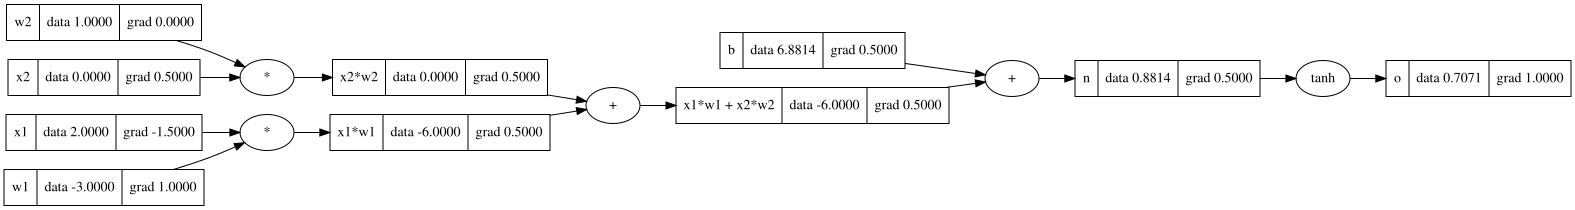

In [73]:
draw_dot(o)

In [66]:
o.grad = 1.0

In [67]:
# o = tanh(n)
# do/dn = d/dn (tanh(n)) = 1-tanh(n)^2 = 1-o^2
1 - o.data**2

0.4999999999999999

In [68]:
n.grad = 0.5

In [69]:
# '+' operator just lets the gradient flow through
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [70]:
# '+' operator just lets the gradient flow through
x1w1.grad = 0.5
x2w2.grad = 0.5

In [71]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

# w2.grad will be 0 and if you think about it,
# intuitively the derivative tells us the influence of
# wiggling w2 on the output, how does the output change
# but the output does not change because we are multiplying by 0
# because it is not changing, there is no derivative

In [72]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

### implementing backprop by manually calling _backward sequentially



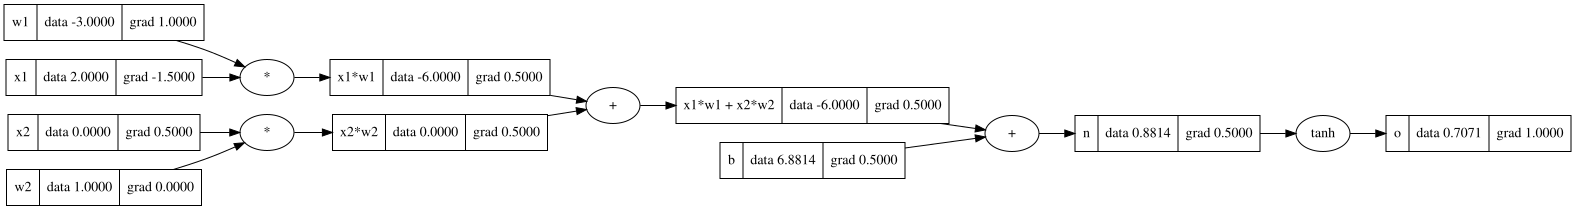

In [97]:
draw_dot(o)

In [91]:
# out.grad is initialized to 0 so as a base case
# we need to set o.grad to 1.0
o.grad = 1.0

The reason ```<var>.backward()``` works is because when ```<var>``` was created during the forward pass, we also store the rule for how to backpropagate through that operation. Later, calling ```<var>.backward()``` executes that stored rule.

In [92]:
o._backward()

In [93]:
n._backward()

In [94]:
b._backward()

In [95]:
x1w1x2w2._backward()

In [96]:
x2w2._backward()
x1w1._backward()

### implementing automatic backprop

In order to call ._backward() at a node, we need to make sure that the gradient of the final output with respect to that node has already been computed. This gradient comes from all nodes that depend on it, meaning all the nodes downstream of it in the computational graph. One way to guarantee the correct order is to first perform a topological sort of the computational graph and then process the nodes in the reverse topological order. The topological sort gives a valid forward order from inputs to output so reversing it gives a valid backward order from output back to inputs.

In the code below, a node gets added to topo only once its children are processed and that is the invariant that is being maintained.

In [98]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

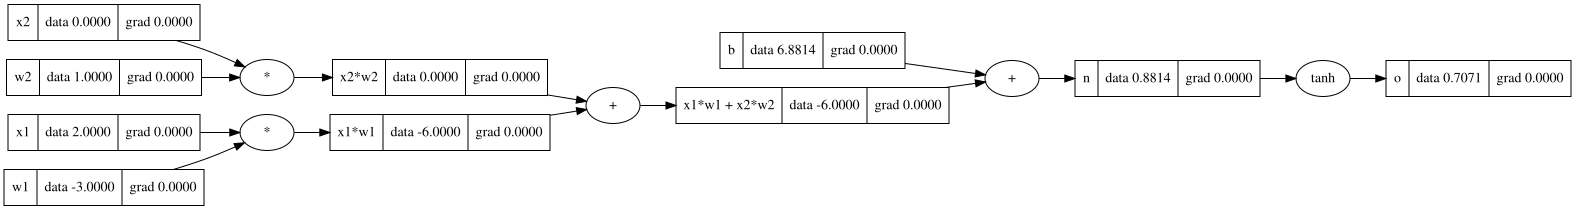

In [100]:
draw_dot(o)

In [101]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()

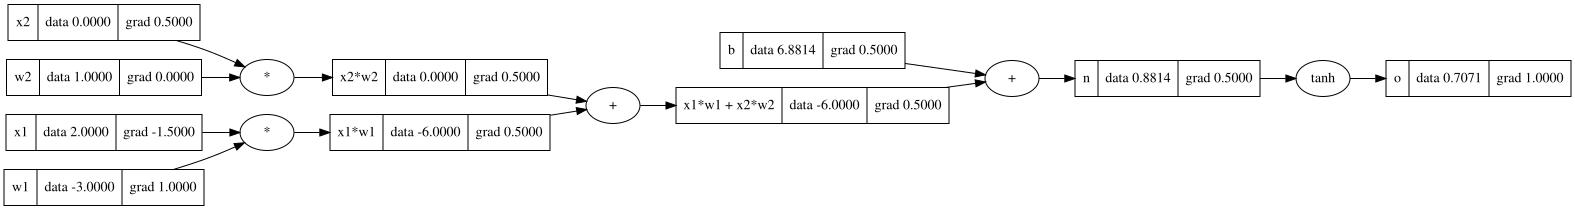

In [102]:
draw_dot(o)

Add this functionality to the Value class!

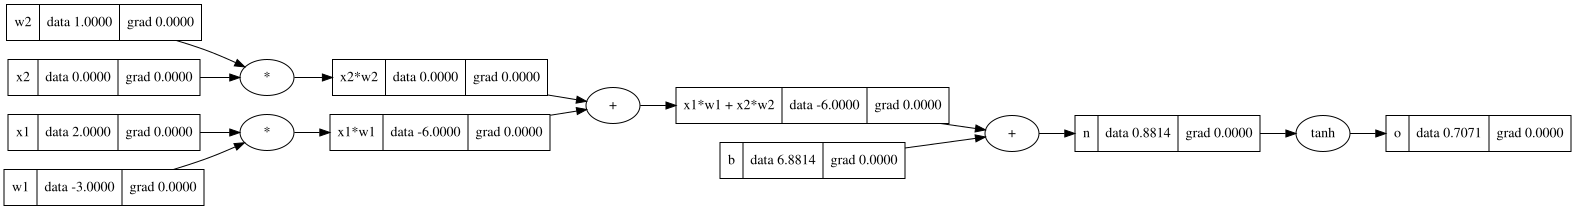

In [104]:
draw_dot(o)

In [105]:
o.backward()

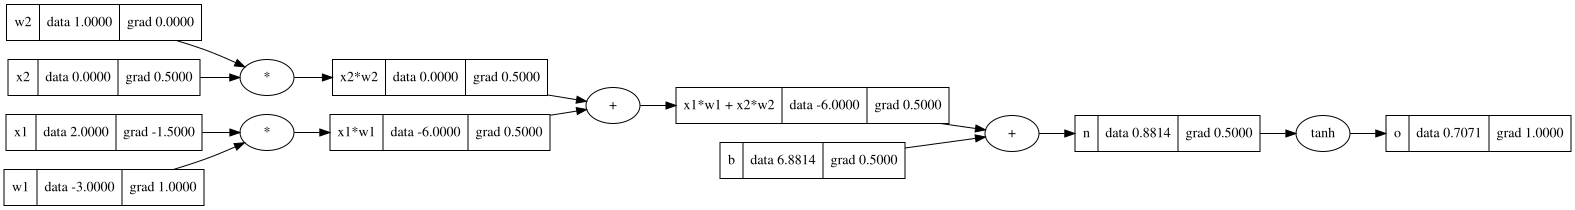

In [106]:
draw_dot(o)

### bug :(
running these cells will no longer give the error because it has been fixed in the ```Value``` class

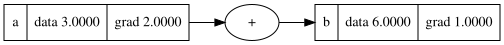

In [53]:
# example 1
a = Value(3.0, label='a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)
# in the graph below there are two arrows on top of each other from a

The reason why this happens is because self and other are the same object so we are overwriting the gradient (setting it to 1 and then setting it to 1 again) and that's why it stays at 1.

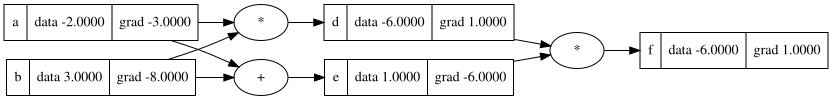

In [54]:
# example 2
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b
d.label = 'd'
e = a + b
e.label = 'e'
f = d*e
f.label = 'f'

f.backward()
draw_dot(f)

If you apply calculus, the gradient of a should be -3.0 and the gradient of b should be -8.0.

### bug fix :)

understanding the math behind the bug fix. Suppose

$$ L = y1 + y2,\ y1 = ax \text{ and } y2 = bx.$$
This means that $x$ affects $L$ through two paths: $x \to y1 \to L \text{ and } x \to y2 \to L$. So,
$$ \frac{dL}{dx} = \frac{dL}{dy1} * \frac{dy1}{dx} + \frac{dL}{dy2} * \frac{dy2}{dx} $$

The fix is to use ```+=``` instead of ```+``` in ```_backward()``` so that we accumulate the gradients. remember that ```.grad``` starts at 0.

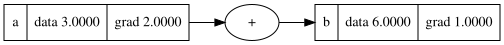

In [107]:
# example 1
a = Value(3.0, label='a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)
# in the graph below there are two arrows on top of each other from a

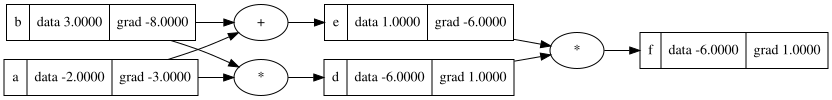

In [108]:
# example 2
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b
d.label = 'd'
e = a + b
e.label = 'e'
f = d*e
f.label = 'f'

f.backward()
draw_dot(f)

testing out if ```__radd__``` and ```__rmul__``` work as expected

In [109]:
apl = Value(2.0)
1+a

Value(data=-1.0)

In [110]:
2*a

Value(data=-4.0)

In [111]:
a*2

Value(data=-4.0)

In [112]:
a+1

Value(data=-1.0)

breaking up $\text{tanh}$ into $\text{exp}$ terms

$$\text{tanh(x)} = \displaystyle \frac{e^{2x}-1}{e^{2x}+1}$$

In [117]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1
x1w1.label = 'x1*w1'
x2w2 = x2*w2
x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

In [114]:
o.backward()

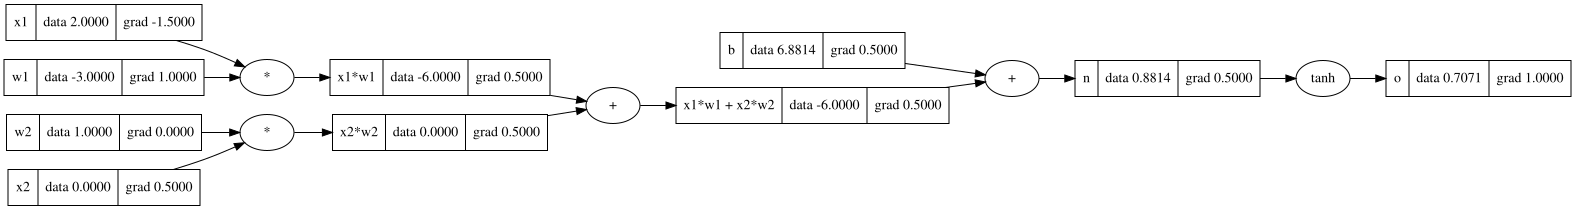

In [115]:
draw_dot(o)

In [118]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1
x1w1.label = 'x1*w1'
x2w2 = x2*w2
x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b
n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'

In [119]:
o.backward()

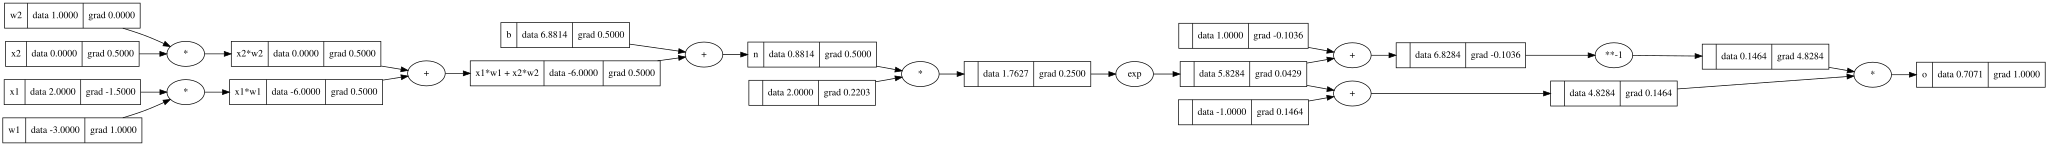

In [120]:
draw_dot(o)

### doing the same thing but using pytorch

In pytorch, everything is based around tensors. Tensors are n-dimensional arrays of scalars.

In [121]:
import torch

In [122]:
# casting it to double because python by default uses double precision
# for floating point numbers whereas by default, torch uses float32
x1 = torch.Tensor([2.0]).double()
# because these are leaf nodes, pytorch assumes that by default these nodes
# do not require gradients, so we need to explicitly say the nodes
# need gradients. They are set to False by default for efficiency reasons
x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()
w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

# just like micrograd, object has a data attribute and a grad attribute
# .item() takes single tensor of one element and it returns the element
# stripping off the tensor
print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [123]:
x2.grad.item()

0.5000001283844369

torch can do what we did in micrograd as a special case when the tensors are all single element tensors but everything is significantly more efficient because we are working with tensor objects and we can do a lot of operations in parallel on all of these tensors.

### building out a neural network

In [124]:
import random

In [155]:
class Neuron:
  # nin is the number of inputs coming to the neuron
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # used when you call an object of Neuron class with a tensor
    # for example: x = [2.0, 3.0]; n = Neuron(2); n(x);
    # n(x) is the __call__

    # w * x + b (dot product)
    # zip takes two iterators and creates a new iterator that
    # iterates over the tuples of the corresponding entries
    # second argument of sum is the start value which is set to b
    activation = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    # non-linearity
    out = activation.tanh()
    return out

  # pytorch also has the exact same thing
  # that returns the parameter tensors
  # whereas for us it is the parameter scalars
  def parameters(self):
    return self.w + [self.b]

In [126]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=0.9494892142812301)

In [158]:
class Layer:
  # nout is the number of neurons in the layer
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
    # read the list comprehension from left to right after p
    # the one line above is the same as:
    # params = []
    # for neuron in self.neurons:
    #   ps = neuron.parameters()
    #   params.extend(ps)
    # return params
    # also, params.extend(ps) is like doing:
    # for p in ps:
    #   params.append(p)

In [128]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=0.17983497608668428),
 Value(data=0.9849415548563064),
 Value(data=-0.17087484646965936)]

In [160]:
class MLP:
  # nouts is the sizes of all layers we want in our MLP
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]
    # params = []
    # for layer in self.layers:
    #   ps = layer.parameters()
    #   params.extend(ps)

    # return params

In [177]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.4521426468299368)

In [166]:
len(n.parameters())

41

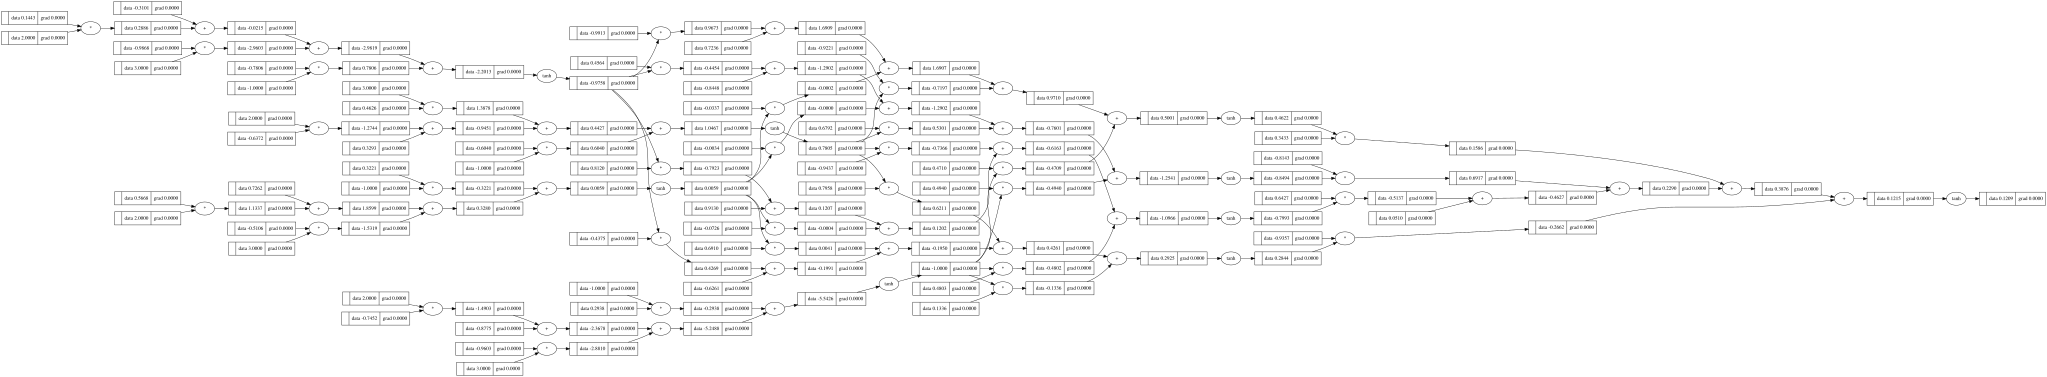

In [162]:
draw_dot(n(x))

In [167]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.12089104982019687),
 Value(data=0.9817641783848197),
 Value(data=0.7321124544274148),
 Value(data=0.21089187262890485)]

loss is a single number that measures how well the neural net is performing. with mse, the further away we are from gt, the greater the loss will be.

In [168]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=8.323126996481175)

In [169]:
loss.backward()

In [172]:
n.layers[0].neurons[0].w[0].data

0.14427956981320555

In [171]:
n.layers[0].neurons[0].w[0].grad

-0.446969060611551

Because the gradient here on this particular weight of this particular neuron of this particular layer is negative, we see that its influence on the loss is also negative meaning that a slight increase in the weight of this neuron of this layer causes the loss to go down.

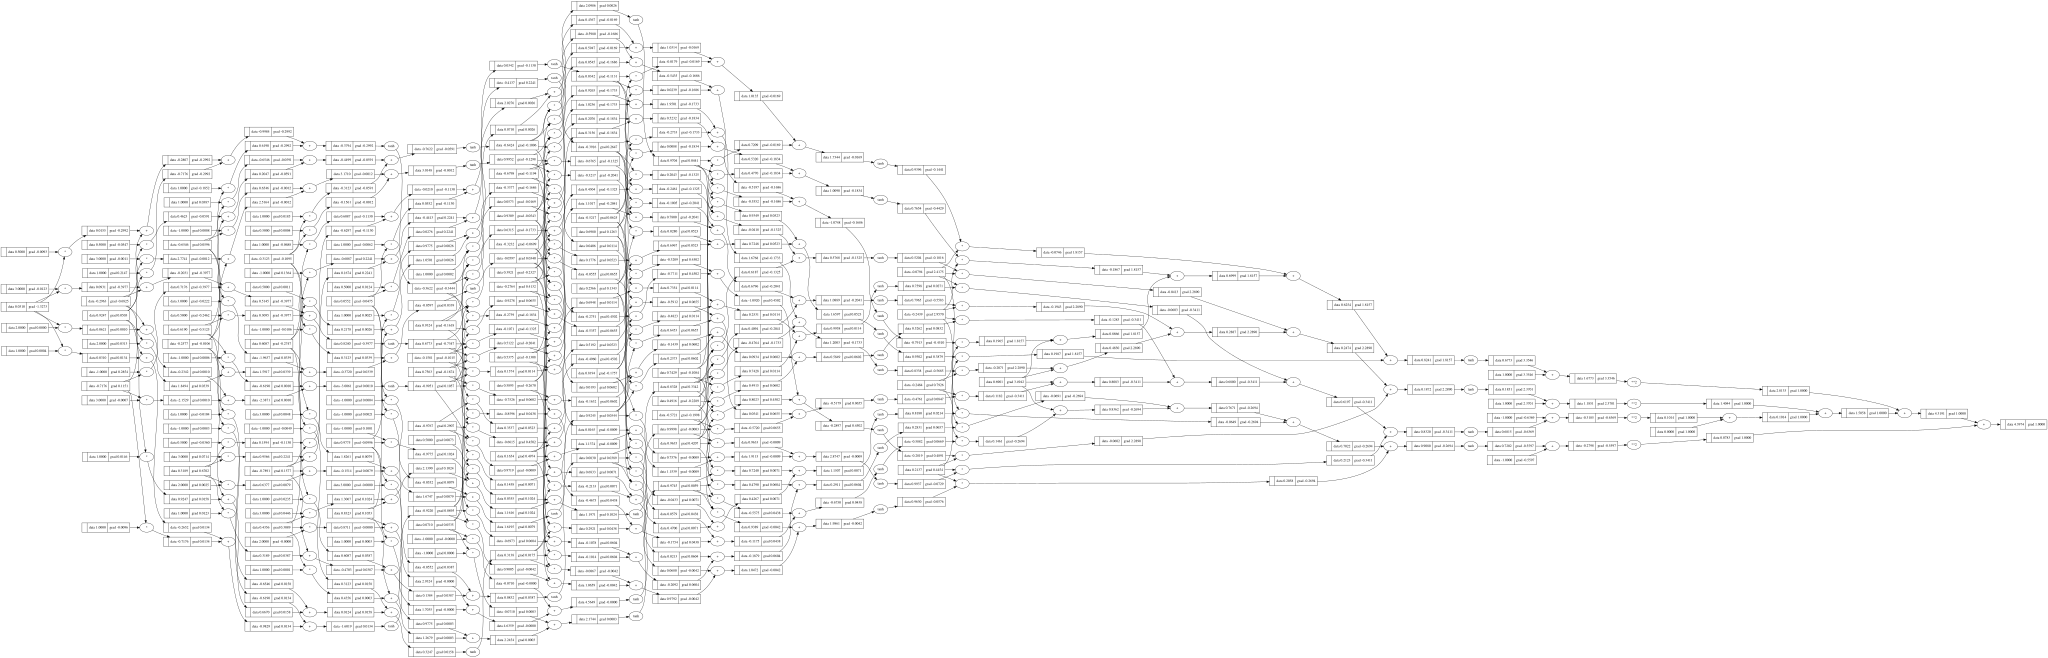

In [154]:
draw_dot(loss)

gradients on the input data is not so useful to us because the input data is assumed to not change and is fixed even though we have gradients for it.

In gradient descent, we are thinking of the gradient as a vector pointing in the direction of increased loss. Since we want to minimize the loss, we go in the opposite direction with a small step size (learning rate) magnitude! for example, ```n.layers[0].neurons[0].w[0].data``` value is ```0.14427956981320555``` and ```n.layers[0].neurons[0].w[0].grad``` is ```-0.446969060611551```. If we update the value of this neuron by ```0.01*grad``` using ```+=```, then we are decreasing its value which in turn increases the loss because its gradient is negative.

In [173]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [174]:
n.layers[0].neurons[0].w[0].data

0.14874926041932107

this neuron is now a tiny amount greater!

In [175]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.674975289329771)

the loss has decreased from $8.32$ to $7.67$!

### gradient descent using a training loop

In [182]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [183]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.30926368812481964)

In [199]:
for k in range(20):
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  # old gradients describe the derivative of the previous loss computation
  # and at the previous parameter values, so we need a clean slate
  # before computing the new gradients
  for p in n.parameters(): # flushing out previous grad
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 0.0034571741305604343
1 0.00343847902754108
2 0.0034199829505744336
3 0.0034016827588306004
4 0.0033835753769115543
5 0.0033656577931622227
6 0.003347927058033365
7 0.0033303802824947745
8 0.0033130146364964445
9 0.0032958273474764867
10 0.0032788156989139857
11 0.003261977028925115
12 0.0032453087289012793
13 0.0032288082421874937
14 0.003212473062799992
15 0.0031963007341814275
16 0.003180288847992368
17 0.003164435042938302
18 0.003148737003630262
19 0.003133192459478569


In [200]:
ypred

[Value(data=0.9803758217013073),
 Value(data=-0.9690846768415827),
 Value(data=-0.9695571764673905),
 Value(data=0.9705795755477132)]